# Minestone 3: Alignment-based approach

In [24]:
import pm4py
import pandas as pd
import os
import csv
import json
import ast
from collections import Counter
from pathlib import Path

from pm4py.objects.log.obj import EventLog, Trace

from pm4py.statistics.variants.log import get as variants_get
from pm4py.algo.conformance.alignments.petri_net import algorithm as aligner

from pm4py.visualization.petri_net import visualizer as pn_visualizer
from pm4py.objects.conversion.process_tree import converter as pt_converter

In [8]:
DATA_DIR = Path.cwd().parent / "data"
OUTPUT_DIR = DATA_DIR / "milestone3"

# Choose which log to use for alignment, dont process all three at once, as it will take a long time to compute
CASE = "clean"  # choose one from ["clean", "noised", "recovered"]

if not OUTPUT_DIR.exists():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Recompute the process model from inductive mining again
- RUN ONCE!!! - uncomment to rerun
- In the milestone 2 we have the runtime problem so we worked on the samples
- For this milestone 3 we work on the original log again

In [ ]:
# log_clean = pm4py.read_xes(str(DATA_DIR / "BPI Challenge 2017.xes.gz"))
# print(f"Loaded clean log: {len(log_clean)} events, "
#         f"{log_clean['case:concept:name'].nunique()} cases")

# log_clean = pm4py.convert_to_event_log(log_clean)

c:\Users\thien\Downloads\Process Mining\ProM-Assignment-Group-C\.venv\Lib\site-packages\pm4py\utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(
c:\Users\thien\Downloads\Process Mining\ProM-Assignment-Group-C\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 31509/31509 [01:09<00:00, 452.89it/s]


Loaded noised log: 954012 events, 31509 cases


In [ ]:
# tree_clean = pm4py.discovery.discover_process_tree_inductive(log_clean)
# net_clean, im_clean, fm_clean = pt_converter.apply(tree_clean)

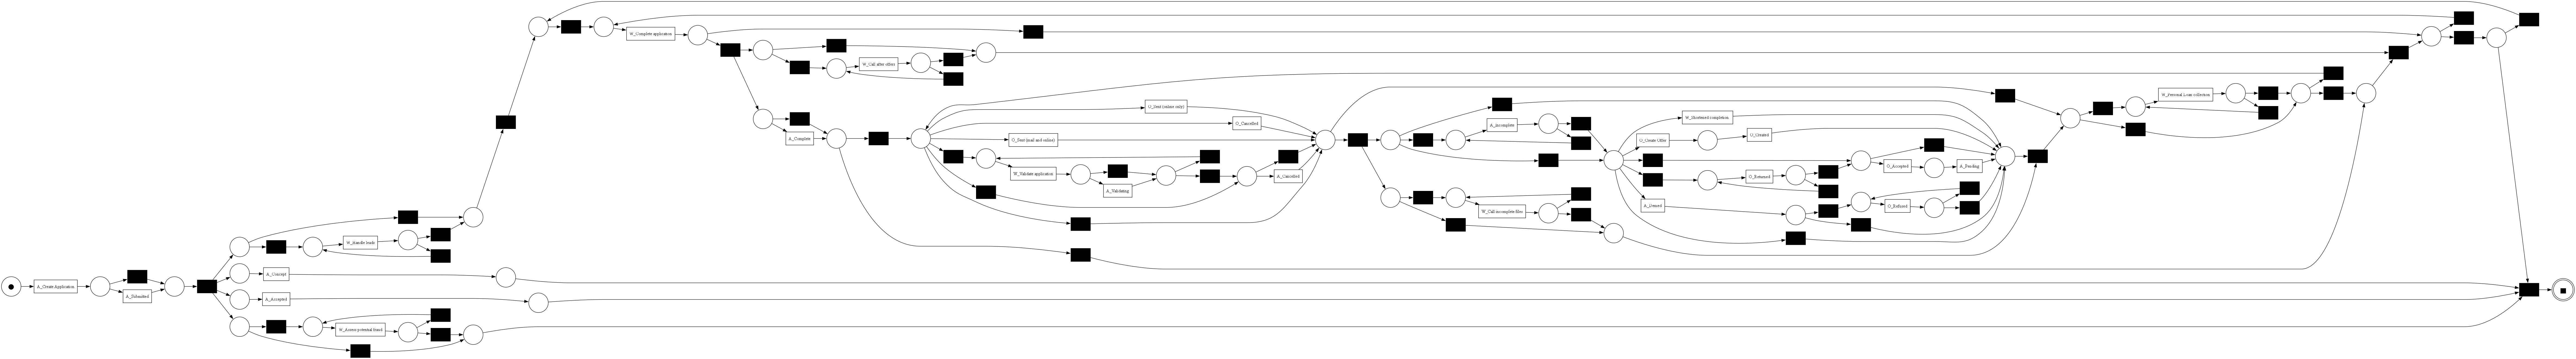

In [ ]:
# gviz = pn_visualizer.apply(net_clean, im_clean, fm_clean)
# pn_visualizer.view(gviz)

In [ ]:
# pm4py.write_pnml(net_clean, im_clean, fm_clean, OUTPUT_DIR / "reference_model_clean.pnml")

## Alignment-Based Conformance

In [9]:
if CASE == "clean":
    log =  pm4py.read_xes(str(DATA_DIR / "BPI Challenge 2017.xes.gz"))
elif CASE == "noised":
    log = pm4py.read_xes(str(DATA_DIR / "noised.xes.gz"))
else: # CASE == "recovered":
    log = pm4py.read_xes(str(DATA_DIR / "recovered.xes.gz"))
print(f"Loaded {CASE} log: {len(log)} events, "
        f"{log['case:concept:name'].nunique()} cases")

# just to make sure that the logs are in the right format for pm4py
log = pm4py.convert_to_event_log(log)

parsing log, completed traces :: 100%|██████████| 31509/31509 [00:53<00:00, 584.08it/s] 


Loaded clean log: 1202267 events, 31509 cases


In [10]:
net_clean, im_clean, fm_clean = pm4py.read_pnml(f"{OUTPUT_DIR}/reference_model_clean.pnml")

In [11]:
variants = variants_get.get_variants(log)
print(len(variants))

15930


### Task a: Compute optimal alignments
- For each trace variant, compute the optimal alignment with the model under the standard cost function (Lecture 11, slide 6). 
- Record, per variant (rows), a table with columns: frequency, alignment cost, move sequence (the alignment), model moves, and log moves. (This per-variant table goes in the repository.)

In [33]:
def classify_and_cost(aligned_trace):
    """
    PM4Py convention:
        - l == ">>"   -> no log move here
        - m == ">>"   -> no model move here
        - m is None   -> model move fired, but on an invisible/tau transition
    Cost function (lecture 11 slide 6):
        - synchronous move: cost 0
        - log move: cost 1
        - model move: cost 1
        - invalid synchronous move: cost infinity
    """
    cost = 0
    log_moves = []
    model_moves = []

    for l, m in aligned_trace:
        log_skip = (l == ">>")
        model_skip = (m == ">>")

        if not log_skip and not model_skip: # SYNCHRONOUS MOVE
            if l != m:
                return float("inf"), [], []
            continue

        elif log_skip and not model_skip: # MODEL MOVE
            if m is not None:  # ignore invisible/tau transitions
                cost += 1
                model_moves.append(m)

        elif model_skip and not log_skip: # LOG MOVE
            if l is not None:  # ignore invisible/tau transitions
                cost += 1
                log_moves.append(l)

    return cost, model_moves, log_moves

In [15]:
output_file = f"alignment_per_variant_{CASE}.csv"

# Load checkpoint
if os.path.exists(OUTPUT_DIR / output_file):
    df_existing = pd.read_csv(OUTPUT_DIR / output_file)
    done_variants = set(df_existing["variant"].astype(str))
else:
    done_variants = set()

processed = 0
for variant, traces in variants.items():
    processed += 1
    if str(variant) in done_variants:
        print(f"Skipping {processed}/{len(variants)}: {variant}")
        continue
    
    # Only need to align one representative trace per variant, since all traces in a variant are identical
    representative = traces[0]

    alignment = aligner.apply_trace(
        representative,
        net_clean,
        im_clean,
        fm_clean
    )

    aligned = alignment["alignment"]

    # Manually classify the alignment and compute the cost of deviations instead of relying on the cost computed by pm4py
    cost, model_moves, log_moves = classify_and_cost(aligned)

    row = {
        "variant": variant,
        "frequency": len(traces),
        "cost": cost,
        "alignment": json.dumps(aligned),
        "model_moves": json.dumps(model_moves),
        "log_moves": json.dumps(log_moves)
    }

    file_exists = os.path.exists(OUTPUT_DIR / output_file)
    with open(OUTPUT_DIR / output_file, "a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=row.keys())
        if not file_exists:
            writer.writeheader()
        writer.writerow(row)

    print(f"Saved variant {processed}/{len(variants)}: {variant} | cost={cost}")

Skipping 1/15930: ('A_Create Application', 'A_Submitted', 'W_Handle leads', 'W_Handle leads', 'W_Complete application', 'A_Concept', 'W_Complete application', 'W_Complete application', 'A_Accepted', 'O_Create Offer', 'O_Created', 'O_Sent (mail and online)', 'W_Complete application', 'W_Call after offers', 'W_Call after offers', 'A_Complete', 'W_Call after offers', 'W_Call after offers', 'W_Call after offers', 'W_Call after offers', 'W_Validate application', 'W_Validate application', 'A_Validating', 'O_Returned', 'W_Validate application', 'W_Validate application', 'W_Call incomplete files', 'W_Call incomplete files', 'A_Incomplete', 'W_Call incomplete files', 'W_Call incomplete files', 'W_Call incomplete files', 'W_Call incomplete files', 'W_Validate application', 'W_Validate application', 'A_Validating', 'W_Validate application', 'O_Accepted', 'A_Pending', 'W_Validate application')
Skipping 2/15930: ('A_Create Application', 'A_Submitted', 'W_Handle leads', 'W_Handle leads', 'W_Complete

KeyboardInterrupt: 

### Task b+c: Aggregate per log and locate hotspots
- For each log, report two figures in a short table: the absolute fitness and the normalised fitness, where the worst-case alignment runs through the whole trace and then the shortest complete model run.
- For each log, count the model moves and log moves per activity across all cases, and report the top five activities by total in a short table: rows are hotspots, columns are activity, model moves and log moves.

In [14]:
CSV_PATHS = {
    "clean":     "alignment_per_variant_clean.csv",
    "noised":    "alignment_per_variant_noised.csv",
    "recovered": "alignment_per_variant_recovered.csv",
}

In [38]:
def shortest_model_run_cost(net, im, fm):
    """Align the EMPTY trace against the model. The resulting cost equals the
    length of the shortest complete firing sequence from im to fm. this is
    the 'worst case model run' needed for normalised fitness."""
    empty_log = EventLog([Trace()])
    alignment = aligner.apply_trace(empty_log[0], net, im, fm)
    aligned = alignment["alignment"]

    cost = 0
    for l, m in aligned:
        log_skip = (l == ">>")
        model_skip = (m == ">>")
        if log_skip and not model_skip:
            if m is not None:  # ignore invisible/tau transitions
                cost += 1
    return cost

In [ ]:
worst_case_model_cost = shortest_model_run_cost(net_clean, im_clean, fm_clean)
print(f"Shortest complete model run cost (model property): {worst_case_model_cost}")

Shortest complete model run cost (model property): 4



In [55]:
def analyse_csv(log_name, csv_path, worst_case_model_cost, top_n):
    df = pd.read_csv(OUTPUT_DIR / csv_path)

    total_weighted_cost = 0
    total_weighted_worst_case = 0
    total_cases = 0

    model_move_counter = Counter()
    log_move_counter = Counter()

    for _, row in df.iterrows():
        freq = int(row["frequency"])
        cost = float(row["cost"])

        # trace length = number of activities in the variant tuple
        variant_tuple = ast.literal_eval(row["variant"])
        trace_len = len(variant_tuple)

        model_moves = json.loads(row["model_moves"])
        log_moves = json.loads(row["log_moves"])

        worst_case_i = trace_len + worst_case_model_cost # in the worst case, we have to do all the log moves (trace_len) and all the model moves (worst_case_model_cost)

        total_weighted_cost += freq * cost
        total_weighted_worst_case += freq * worst_case_i
        total_cases += freq

        for act in model_moves:
            model_move_counter[act] += freq
        for act in log_moves:
            log_move_counter[act] += freq

    # ---- Task 2b ----
    absolute_total_cost = total_weighted_cost
    normalised_fitness = 1 - (total_weighted_cost / total_weighted_worst_case)

    aggregate_row = {
        "log": log_name,
        "n_cases": total_cases,
        "n_variants": len(df),
        "absolute_total_cost": int(absolute_total_cost),
        "normalised_fitness": round(normalised_fitness, 4),
    }

    # ---- Task 2c ----
    all_activities = set(model_move_counter) | set(log_move_counter)
    hotspot_rows = []
    if len(all_activities) == 0:
        print(f"Warning: No activities found in log {log_name}. Skipping hotspot analysis.")
        df_hotspots = pd.DataFrame(columns=["activity", "model_moves", "log_moves"])
    else:
        for act in all_activities:
            mm = model_move_counter.get(act, 0)
            lm = log_move_counter.get(act, 0)
            hotspot_rows.append({"activity": act, "model_moves": mm, "log_moves": lm, "total": mm + lm})

        df_hotspots = (
            pd.DataFrame(hotspot_rows)
            .sort_values("total", ascending=False)
            .head(top_n)
            .drop(columns="total")
            .reset_index(drop=True)
        )

    return aggregate_row, df_hotspots

In [56]:
aggregate_rows = []
hotspot_tables = {}

for log_name, csv_path in CSV_PATHS.items():
    agg_row, df_hotspots = analyse_csv(log_name, csv_path, worst_case_model_cost, top_n=5)
    aggregate_rows.append(agg_row)
    hotspot_tables[log_name] = df_hotspots

    print(f"=== Task 2c: Top-5 hotspot activities -- {log_name} ===")
    print(df_hotspots.to_string(index=False))

df_aggregate = pd.DataFrame(aggregate_rows)
df_aggregate.to_csv(OUTPUT_DIR / "2b_aggregate_fitness.csv", index=False)
print("=== Task 2b: Aggregate fitness per log ===")
print(df_aggregate.to_string(index=False))

for log_name, df_hotspots in hotspot_tables.items():
    df_hotspots.to_csv(OUTPUT_DIR / f"2c_hotspots_{log_name}.csv", index=False)

=== Task 2c: Top-5 hotspot activities -- clean ===
Empty DataFrame
Columns: [activity, model_moves, log_moves]
Index: []
=== Task 2c: Top-5 hotspot activities -- noised ===
              activity  model_moves  log_moves
W_Finalize application            0       1189
  W_Finish application            0       1166
            A_Complete            0        587
    W_Call after ofrs.            0        448
      W_Complete appl.            0        351
=== Task 2c: Top-5 hotspot activities -- recovered ===
  activity  model_moves  log_moves
A_Complete            0       2554
 A_Pending            0        351
O_Accepted            0        351
=== Task 2b: Aggregate fitness per log ===
      log  n_cases  n_variants  absolute_total_cost  normalised_fitness
    clean     4255          99                    0              1.0000
   noised     2718        1279                 5753              0.9280
recovered     2554          18                 3256              0.9495
